<a href="https://colab.research.google.com/github/nithyaak7/DADS5250/blob/main/M02_Lab1_Excel_GPT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- dads-lab-header -->
<a href="https://colab.research.google.com/github/mdehghani86/DADS5250-GenAI/blob/main/labs/M02/M02_Lab1_Excel_GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); padding: 30px 36px; border-radius: 14px; margin-bottom: 20px;">
  <h1 style="color: #fff; margin: 0; font-size: 28px;">📊 M02 Lab 1 — Excel GPT</h1>
  <p style="color: rgba(255,255,255,0.85); margin: 8px 0 0; font-size: 15px;">DADS 5250: Generative AI in Practice &nbsp;|&nbsp; Prof. Dehghani</p>
  <p style="color: rgba(255,255,255,0.65); margin: 6px 0 0; font-size: 13px;">⭐ Difficulty: Beginner &nbsp;|&nbsp; ⏱ Time: ~25 min</p>
</div>

> **📌 Note on models.** This lab references specific LLM versions through `DEFAULT_CHAT_MODEL` and `DEFAULT_MINI_MODEL` constants in the `dads5250` utility package. Models update quickly — feel free to swap to any newer OpenAI / Anthropic / Google model you have access to.


In [2]:
# === Shared lab setup: install dads5250 + load API key + sticky pill ===
# Installs the shared utilities (pp, pretty_print, lab_pill, model constants,
# setup_openai, setup_gemini) once per Colab runtime. The same OPENAI_API_KEY
# / GEMINI_API_KEY Colab secrets are used across every DADS 5250 lab — set
# them once in the 🔑 sidebar and they're picked up automatically.
import os
import importlib.util
if importlib.util.find_spec("dads5250") is None:
    !pip install -q "git+https://github.com/mdehghani86/DADS5250-GenAI.git#subdirectory=utils"

from dads5250 import (
    pp,
    pretty_print,
    lab_pill,
    setup_openai,
    setup_gemini,
    DEFAULT_CHAT_MODEL,   # newest reasoning model that supports temperature
    DEFAULT_MINI_MODEL,   # newest mini model that supports temperature
    DEFAULT_EMBED_MODEL,  # current embeddings default
    DEFAULT_GEMINI_MODEL, # tracks the latest stable flash
)

lab_pill('M02 Lab 1 — Excel GPT')            # sticky banner so you always see which lab you're in
client = setup_openai()        # loads OPENAI_API_KEY + verifies it works


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.5 MB/s eta 0:00:00


OpenAI ready  |  model: gpt-5.4-mini  |  status: connected


In [3]:
# === Shared lab setup: install dads5250 + load API key + sticky pill ===
# Installs the shared utilities (pp, pretty_print, lab_pill, model constants,
# setup_openai, setup_gemini) once per Colab runtime. The same OPENAI_API_KEY
# / GEMINI_API_KEY Colab secrets are used across every DADS 5250 lab — set
# them once in the 🔑 sidebar and they're picked up automatically.
import importlib.util
if importlib.util.find_spec("dads5250") is None:
    !pip install -q "git+https://github.com/mdehghani86/DADS5250-GenAI.git#subdirectory=utils"

from dads5250 import (
    pp,
    pretty_print,
    lab_pill,
    setup_openai,
    setup_gemini,
    DEFAULT_CHAT_MODEL,   # newest reasoning model that supports temperature
    DEFAULT_MINI_MODEL,   # newest mini model that supports temperature
    DEFAULT_EMBED_MODEL,  # current embeddings default
    DEFAULT_GEMINI_MODEL, # tracks the latest stable flash
)

lab_pill('M02 Lab 1 — Excel GPT')            # sticky banner so you always see which lab you're in
client = setup_openai()        # loads OPENAI_API_KEY + verifies it works


OpenAI ready  |  model: gpt-5.4-mini  |  status: connected


In [4]:
# ============================================================
# 🔑 API Key & Client Setup
# ============================================================
from openai import OpenAI
from dads5250 import setup_openai, pp, show_response, show_expected, show_info, compare_responses, estimate_cost, count_tokens, quiz
import pandas as pd

# This reads your OPENAI_API_KEY from Colab Secrets automatically
client = setup_openai()

OpenAI ready  |  model: gpt-5.4-mini  |  status: connected


<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); padding: 18px 24px; border-radius: 10px; margin: 20px 0 12px;">
  <h2 style="color: white; margin: 0; font-size: 20px;">1️⃣ Loading Sample Data</h2>
</div>

First, let's create a realistic sales dataset — the kind of data you'd normally analyze manually in Excel. Today, AI does it for you.

In [5]:
# ============================================================
# 📊 Create Sample Sales Dataset
# ============================================================

data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    "Product_Category": ["Electronics", "Clothing", "Electronics", "Home",
                         "Clothing", "Electronics", "Home", "Clothing",
                         "Electronics", "Home", "Clothing", "Electronics"],
    "Revenue": [45200, 38100, 52400, 31800, 41500, 58700,
                29400, 43600, 61200, 35900, 47800, 72100],
    "Units_Sold": [152, 203, 178, 145, 210, 189,
                   132, 215, 195, 148, 225, 201],
    "Returns": [12, 18, 9, 15, 22, 7, 19, 14, 8, 21, 11, 6]
}

df = pd.DataFrame(data)
print("📋 Sample Sales Data (12 months):\n")
display(df)

# Save to CSV for reference
df.to_csv("sales_data.csv", index=False)
print("\n✅ Saved to sales_data.csv")

📋 Sample Sales Data (12 months):



,Month,Product_Category,Revenue,Units_Sold,Returns
0,Jan,Electronics,45200,152,12
1,Feb,Clothing,38100,203,18
2,Mar,Electronics,52400,178,9
3,Apr,Home,31800,145,15
4,May,Clothing,41500,210,22
5,Jun,Electronics,58700,189,7
6,Jul,Home,29400,132,19
7,Aug,Clothing,43600,215,14
8,Sep,Electronics,61200,195,8
9,Oct,Home,35900,148,21



✅ Saved to sales_data.csv


<div style="background: #f0f4ff; border-left: 4px solid #0055d4; padding: 14px 18px; border-radius: 0 8px 8px 0; margin: 12px 0; font-size: 14px;">
  <b>🧠 Key Idea:</b> This is a typical spreadsheet you'd open in Excel and manually write formulas for — totals, growth rates, conditional formatting. Instead, we'll ask an LLM to write those formulas and macros for us.
</div>

<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); padding: 18px 24px; border-radius: 10px; margin: 20px 0 12px;">
  <h2 style="color: white; margin: 0; font-size: 20px;">2️⃣ AI Writes Excel Formulas</h2>
</div>

The trick to getting **paste-ready** Excel formulas from an LLM is a strict system message. We tell the model to return **only** the formula — no explanation, no markdown.

In [6]:
# ============================================================
# 📐 System Message for Formula Generation
# ============================================================

FORMULA_SYSTEM = """You are an Excel expert. When given data and a request, generate the exact Excel formula needed.
Return ONLY the formula, no explanation. Do not wrap it in markdown or code blocks."""

DATA_DESCRIPTION = """Excel spreadsheet with columns:
A: Month (A2:A13 = Jan through Dec)
B: Product_Category (B2:B13)
C: Revenue (C2:C13, numbers like 45200)
D: Units_Sold (D2:D13)
E: Returns (E2:E13)
Row 1 is headers. Data is in rows 2-13."""

print("✅ System message and data description ready.")

✅ System message and data description ready.


In [7]:
# ============================================================
# 📐 Example 1: Total Revenue
# ============================================================

request_1 = "Calculate the total revenue across all months."

r1 = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {"role": "system", "content": FORMULA_SYSTEM},
        {"role": "user", "content": f"Data: {DATA_DESCRIPTION}\n\nRequest: {request_1}"}
    ],
    max_tokens=100,
)

pp({"request": request_1, "formula": r1.choices[0].message.content.strip(), "expected": "=SUM(C2:C13)"}, "Formula Generation")

In [9]:
# ============================================================
# 📐 Example 2: Month-over-Month Growth Rate
# ============================================================

request_2 = "Calculate the month-over-month revenue growth rate for March (row 4) compared to February (row 3). Show as a percentage."

r2 = client.chat.completions.create(
    model=DEFAULT_MINI_MODEL,
    messages=[
        {"role": "system", "content": FORMULA_SYSTEM},
        {"role": "user", "content": f"Data: {DATA_DESCRIPTION}\n\nRequest: {request_2}"}
    ],
    max_completion_tokens=100,
)

formula_2 = r2.choices[0].message.content.strip()
print(f"📌 Request:  {request_2}")
print(f"📐 Formula:  {formula_2}")
print(f"\n   This formula calculates: (Mar Revenue - Feb Revenue) / Feb Revenue")

📌 Request:  Calculate the month-over-month revenue growth rate for March (row 4) compared to February (row 3). Show as a percentage.
📐 Formula:  =(C4-C3)/C3

   This formula calculates: (Mar Revenue - Feb Revenue) / Feb Revenue


In [10]:
# ============================================================
# 📐 Example 3: Conditional Formula
# ============================================================

request_3 = "Write a formula for cell F2 that shows 'High Returns' if returns (E2) are greater than 15, otherwise 'Normal'. This formula will be copied down to F13."

r3 = client.chat.completions.create(
    model=DEFAULT_MINI_MODEL,
    messages=[
        {"role": "system", "content": FORMULA_SYSTEM},
        {"role": "user", "content": f"Data: {DATA_DESCRIPTION}\n\nRequest: {request_3}"}
    ],
    max_completion_tokens=100,
)

formula_3 = r3.choices[0].message.content.strip()
print(f"📌 Request:  {request_3}")
print(f"📐 Formula:  {formula_3}")
print(f"\n   This uses IF() — one of Excel's most common functions.")

📌 Request:  Write a formula for cell F2 that shows 'High Returns' if returns (E2) are greater than 15, otherwise 'Normal'. This formula will be copied down to F13.
📐 Formula:  =IF(E2>15,"High Returns","Normal")

   This uses IF() — one of Excel's most common functions.


<div style="background: #fff8e1; border-left: 4px solid #f9a825; padding: 12px 16px; border-radius: 0 8px 8px 0; margin: 12px 0;">
  <b>💡 Pro Tip:</b> Notice we use a strict system message — <i>"Return ONLY the formula."</i> Without this, the model adds explanations and markdown code blocks that break when pasted into Excel. The system message is your most powerful tool for controlling output format.
</div>

**📝 Your Observations:** *(double-click to edit)*

1. Run the same formula request 3 times. Are the formulas identical each time? _[Your answer]_
2. Does the AI-generated formula look correct? Would you trust it without testing in Excel? _[Your answer]_

<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); padding: 18px 24px; border-radius: 10px; margin: 20px 0 12px;">
  <h2 style="color: white; margin: 0; font-size: 20px;">3️⃣ AI Writes VBA Macros</h2>
</div>

VBA (Visual Basic for Applications) is Excel's built-in programming language. It automates repetitive tasks — formatting, chart creation, data processing. Writing VBA from scratch is tedious. Let's have AI do it.

In [11]:
# ============================================================
# 🔧 System Message for VBA Generation
# ============================================================

VBA_SYSTEM = """You are a VBA expert. Generate clean, commented VBA macros for Excel.
Return only the VBA code. Do not wrap it in markdown code blocks.
Always add comments explaining each section of the macro."""

print("✅ VBA system message ready.")

✅ VBA system message ready.


In [12]:
# ============================================================
# 🔧 VBA Example 1: Format Top Revenue Months
# ============================================================

vba_request_1 = """Write a VBA macro that:
1. Looks at revenue values in column C (rows 2-13)
2. Finds the top 3 revenue months
3. Formats those cells with bold text, green background color, and a thick border"""

v1 = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {"role": "system", "content": VBA_SYSTEM},
        {"role": "user", "content": f"Data: {DATA_DESCRIPTION}\n\nRequest: {vba_request_1}"}
    ],
    max_tokens=600,
)

pp(v1.choices[0].message.content.strip(), "VBA — Format Top 3 Revenue Months")

In [13]:
# ============================================================
# 🔧 VBA Example 2: Create a Bar Chart
# ============================================================

vba_request_2 = """Write a VBA macro that:
1. Creates a bar chart from the monthly revenue data (A1:A13 for labels, C1:C13 for values)
2. Sets the chart title to 'Monthly Revenue'
3. Places the chart below the data starting at cell A16
4. Uses blue bars"""

v2 = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {"role": "system", "content": VBA_SYSTEM},
        {"role": "user", "content": f"Data: {DATA_DESCRIPTION}\n\nRequest: {vba_request_2}"}
    ],
    max_tokens=600,
)

pp(v2.choices[0].message.content.strip(), "VBA — Create Bar Chart")

### How to Use VBA in Excel

To run the generated VBA macros in Excel:

1. **Open the VBA Editor:** Press `Alt + F11` in Excel
2. **Insert a Module:** Click `Insert` → `Module`
3. **Paste the Code:** Copy the generated VBA code and paste it into the module
4. **Run the Macro:** Press `F5` or go to `Run` → `Run Sub`

Alternatively:
- Go to the **Developer** tab → **Visual Basic** → **Insert Module** → Paste → **Run**
- If you don't see the Developer tab: `File` → `Options` → `Customize Ribbon` → Check `Developer`

> *See the Module 2 video for a step-by-step walkthrough of running VBA macros in Excel.*

<div style="background: #fff8e1; border-left: 4px solid #f9a825; padding: 12px 16px; border-radius: 0 8px 8px 0; margin: 12px 0;">
  <b>💡 Pro Tip:</b> Same API, different system message, completely different output. The formula system message produces a single-line formula. The VBA system message produces a full multi-line macro with comments. This is the power of prompt engineering — you control the <i>shape</i> of the output.
</div>

<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); padding: 18px 24px; border-radius: 10px; margin: 20px 0 12px;">
  <h2 style="color: white; margin: 0; font-size: 20px;">4️⃣ Building a Reusable Excel GPT Function</h2>
</div>

Let's wrap everything into a clean, reusable function. One function, three modes — formula, VBA, and analysis — all controlled by the system message.

In [16]:
# ============================================================
# 🛠️ Reusable Excel GPT Function
# ============================================================

def excel_gpt(data_description, request, mode="formula"):
    """Ask AI to generate Excel formulas, VBA macros, or data analysis.

    Args:
        data_description: A string describing the spreadsheet layout and data.
        request: What you want the AI to generate (natural language).
        mode: One of 'formula', 'vba', or 'analysis'.

    Returns:
        The generated formula, VBA code, or analysis as a string.
    """
    system = {
        "formula": "You are an Excel formula expert. Return ONLY the Excel formula, nothing else. Do not wrap it in markdown or code blocks.",
        "vba": "You are a VBA expert. Return ONLY clean, commented VBA code. Do not wrap it in markdown code blocks.",
        "analysis": "You are a data analyst. Analyze the data and provide insights with specific numbers. Be concise — 3-5 bullet points max."
    }

    response = client.chat.completions.create(
        model=DEFAULT_MINI_MODEL,
        messages=[
            {"role": "system", "content": system[mode]},
            {"role": "user", "content": f"Data: {data_description}\n\nRequest: {request}"}
        ],
        max_completion_tokens=500,
    )
    return response.choices[0].message.content.strip()

print("✅ excel_gpt() function defined — ready to use!")

✅ excel_gpt() function defined — ready to use!


In [17]:
# ============================================================
# 🛠️ Demo: Formula Mode
# ============================================================

result = excel_gpt(
    DATA_DESCRIPTION,
    "Calculate the average revenue for Electronics products only.",
    mode="formula"
)
pp({"mode": "formula", "result": result}, "Excel GPT — Formula Mode")

In [18]:
# ============================================================
# 🛠️ Demo: VBA Mode
# ============================================================

result = excel_gpt(
    DATA_DESCRIPTION,
    "Write a macro that adds a new column F with header 'Revenue per Unit' and calculates C/D for each row.",
    mode="vba"
)
pp(result, "Excel GPT — VBA Mode")

In [19]:
# ============================================================
# 🛠️ Demo: Analysis Mode
# ============================================================

# For analysis mode, let's give it the actual numbers
detailed_data = f"{DATA_DESCRIPTION}\n\nActual values:\n{df.to_string(index=False)}"

result = excel_gpt(
    detailed_data,
    "What are the key trends in this sales data? Which category performs best?",
    mode="analysis"
)
pp(result, "Excel GPT — Analysis Mode")

<div style="background: #f0f4ff; border-left: 4px solid #0055d4; padding: 14px 18px; border-radius: 0 8px 8px 0; margin: 12px 0; font-size: 14px;">
  <b>🧠 Key Takeaway:</b> The <code>excel_gpt()</code> function demonstrates a core prompt engineering pattern: <b>same API call, different system messages, different output types</b>. The model is the same — it's the system prompt that controls whether you get a formula, code, or prose.
</div>

<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); padding: 18px 24px; border-radius: 10px; margin: 20px 0 12px;">
  <h2 style="color: white; margin: 0; font-size: 20px;">📝 Knowledge Check</h2>
</div>

In [21]:
# ============================================================
# 📝 Quiz — Test Your Understanding
# ============================================================

quiz([
    {
        "q": "Why do we use a strict system message like 'Return ONLY the formula' when generating Excel formulas?",
        "options": [
            "To make the API call faster",
            "To prevent extra text and markdown that breaks when pasted into Excel",
            "Because the model can only generate formulas with this instruction",
            "To reduce the number of tokens in the response"
        ],
        "answer": 1,
        "explanation": "Without a strict system message, the model adds explanations, markdown code blocks, and commentary. This extra text breaks when you paste it directly into an Excel cell. The system message controls the output format."
    },
    {
        "q": "What is the keyboard shortcut to open the VBA Editor in Excel?",
        "options": [
            "Ctrl + F11",
            "Alt + F11",
            "Shift + F11",
            "Ctrl + Shift + V"
        ],
        "answer": 1,
        "explanation": "Alt + F11 opens the Visual Basic for Applications (VBA) editor in Excel. From there you can insert a module and paste AI-generated VBA code."
    }
])

<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); padding: 18px 24px; border-radius: 10px; margin: 20px 0 12px;">
  <h2 style="color: white; margin: 0; font-size: 20px;">🔧 Hands-On Exercise</h2>
</div>

### Exercise: Extend the Excel GPT

Add **two new modes** to the `excel_gpt` function and test them. Replace each `-----` with the correct value.

In [25]:
# ============================================================
# 🔧 Exercise: Extended Excel GPT
# ============================================================
# Replace each ----- with the correct value

def excel_gpt_extended(data_description, request, mode="formula"):
    """Extended Excel GPT with 5 modes."""
    system = {
        "formula": "You are an Excel formula expert. Return ONLY the Excel formula, nothing else.",
        "vba": "You are a VBA expert. Return ONLY clean, commented VBA code.",
        "analysis": "You are a data analyst. Provide insights with specific numbers. 3-5 bullet points.",
        # 👇 YOUR CODE: Add two new modes
        "pivot": "You are an Excel expert. Suggest the best Pivot Table configuration (Rows, Columns, Values, Filters) for the user's request.",
        "chart": "You are a data visualization expert. Recommend the best chart type for this data and provide a brief reasoning why.",
      }

    response = client.chat.completions.create(
        model="gpt-4.1-mini",                          # Which model should we use?
        messages=[
            {"role": "system", "content": system[mode]},   # What role is the system message?
            {"role": "user", "content": f"Data: {data_description}\n\nRequest: {request}"}
        ],
        max_tokens=250,                        # Pick an appropriate token limit
    )
    return response.choices[0].message.content.strip()  # How do we access the text?

In [26]:
# ============================================================
# 🔧 Exercise (continued): Test Your New Modes
# ============================================================

# Test Mode 1 — replace ----- with your first new mode name and a request
result_1 = excel_gpt_extended(
    DATA_DESCRIPTION,
    "I need to summarize the total revenue and group it by quarter.",       # YOUR CODE: Write a request that matches your new mode
    mode="pivot"    # YOUR CODE: Use your new mode name
)
print(f"🆕 Mode 1 Result:\n{result_1}")
print()

# Test Mode 2 — replace ----- with your second new mode name and a request
result_2 = excel_gpt_extended(
    DATA_DESCRIPTION,
    "I want to visualize the month-over-month revenue trend to see if our sales are growing.",       # YOUR CODE: Write a request that matches your new mode
    mode="chart"    # YOUR CODE: Use your new mode name
)
print(f"🆕 Mode 2 Result:\n{result_2}")

🆕 Mode 1 Result:
For summarizing total revenue grouped by quarter in a Pivot Table, use this configuration:

- Rows: Group the "Month" field by Quarter (Excel can group months into quarters automatically)
- Values: Sum of "Revenue"

Optional steps:
- Add the "Month" field to Rows
- Right-click a month in the pivot, select Group..., then choose "Quarters" (and optionally "Months" if you want more detail)
- Remove "Month" from Rows if you only want quarters

No Columns or Filters are needed unless you want to further segment the data.

Summary:
- Rows: Month (grouped by Quarters)
- Values: Sum of Revenue
- Columns: (leave blank)
- Filters: (leave blank)

🆕 Mode 2 Result:
The best chart type for visualizing the month-over-month revenue trend is a **line chart**.

**Reasoning:**
- A line chart clearly shows how revenue changes over time (months in this case), making it easy to spot trends, seasonality, and overall growth.
- Plotting months on the x-axis and revenue on the y-axis allows you

In [27]:
# ============================================================
# 💰 Lab Cost Summary
# ============================================================
# Estimate the total cost of all API calls made during this lab
# (Approximate: ~6 calls, avg 200 input + 150 output tokens each)

total_cost = estimate_cost(200 * 6, 150 * 6)
pp(total_cost, "Estimated Total Lab Cost (all API calls)")

**📝 Your Observations:** *(double-click to edit this cell)*

1. What two new modes did you add? Why did you choose those system messages?

I went with "pivot" and "chart". I set up the pivot prompt to specifically ask for the Rows, Columns, Values, and Filters because otherwise, the AI might just give a vague answer instead of actual steps. For the chart mode, I made sure the prompt tells it to explain why it picked a certain chart, so the user actually learns the reasoning behind the design choice

2. How does the output differ between your new modes and the original three?

The original three modes are mostly about giving you hard data or code—spitting out a formula, writing a VBA script you can copy-paste, or giving numerical insights. The two new ones act more like an Excel tutor. They tell you how to set up your workspace (like where to drag pivot fields) or give design advice for visuals, rather than just doing the math for you.

3. Did you need to adjust the `max_tokens` for any mode? Why or why not?

Yeah, I bumped max_tokens up to 250. 100 tokens is totally fine if it's just writing a single Excel formula, but it's way too short if the AI is trying to write a commented VBA script or explain a chart recommendation. I increased it so the text wouldn't cut off in the middle of a sentence during the longer explanations.

<div style="background: #e8f5e9; border-left: 4px solid #4caf50; padding: 14px 18px; border-radius: 0 8px 8px 0; margin: 12px 0;">
  <h3 style="margin: 0 0 8px;">📖 Self-Study Activity</h3>
  <p style="margin: 0; font-size: 14px;">Take your Excel GPT further:</p>
  <ol style="font-size: 14px;">
    <li>Load a <b>real dataset</b> — your own CSV or a public one — and use <code>excel_gpt()</code> to generate formulas for it</li>
    <li>Open the generated formulas and VBA macros <b>in Excel</b> and verify they work correctly</li>
    <li>Try asking for a <b>complex nested formula</b> (e.g., VLOOKUP + IF + SUMIFS) — how well does the model handle it?</li>
  </ol>
  <p style="margin: 8px 0 0; font-size: 14px;"><b>Assignment:</b> Submit your modified notebook with 2 new modes added to the <code>excel_gpt</code> helper. Include screenshots of at least one formula and one VBA macro tested in Excel.</p>
</div>

In [28]:
# ============================================================
# 🔧 Final Assignment Steps: Real Data, Complex Formula, and VBA
# ============================================================

# 1. Define our dataset description
MY_DATA_DESC = """
Columns A to E. Row 1 has headers: Salesperson, Region, Product, Sales, Target.
Data is in rows 2 through 5.
"""

# 2. Ask for a complex nested formula
complex_request = """
Write a nested formula using IF, VLOOKUP, and SUMIFS.
Cell G2 contains a Salesperson's name.
Check if their Region (lookup columns A:B) is 'North'.
If true, sum all their Sales (column D) where the Product (column C) is 'Laptops'.
If false, return 'Not North'.
"""

complex_formula = excel_gpt_extended(MY_DATA_DESC, complex_request, mode="formula")
print(f"🧠 Complex Formula:\n{complex_formula}\n")

# 3. Ask for a VBA Macro
vba_request = """
Write a VBA macro that loops through rows 2 to 5.
If the Sales value in column D is greater than or equal to the Target in column E,
change the interior color of that Sales cell to green.
"""

vba_macro = excel_gpt_extended(MY_DATA_DESC, vba_request, mode="vba")
print(f"🤖 VBA Macro:\n{vba_macro}")

🧠 Complex Formula:
=IF(VLOOKUP(G2,A:B,2,FALSE)="North",SUMIFS(D2:D5,A2:A5,G2,C2:C5,"Laptops"),"Not North")

🤖 VBA Macro:
```vba
Sub HighlightSalesMeetingTarget()
    Dim ws As Worksheet
    Dim i As Long
    Dim salesVal As Double
    Dim targetVal As Double
    
    ' Set the worksheet to the active sheet
    Set ws = ActiveSheet
    
    ' Loop through rows 2 to 5
    For i = 2 To 5
        ' Get the Sales value from column D
        salesVal = ws.Cells(i, "D").Value
        ' Get the Target value from column E
        targetVal = ws.Cells(i, "E").Value
        
        ' Check if Sales is greater than or equal to Target
        If salesVal >= targetVal Then
            ' Change the interior color of the Sales cell to green
            ws.Cells(i, "D").Interior.Color = vbGreen
        Else
            ' If not meeting target, clear any fill color
            ws.Cells(i, "D").Interior.ColorIndex = xlNone
        End If
    Next i
End Sub
```


Please check the attached output image from Excel.

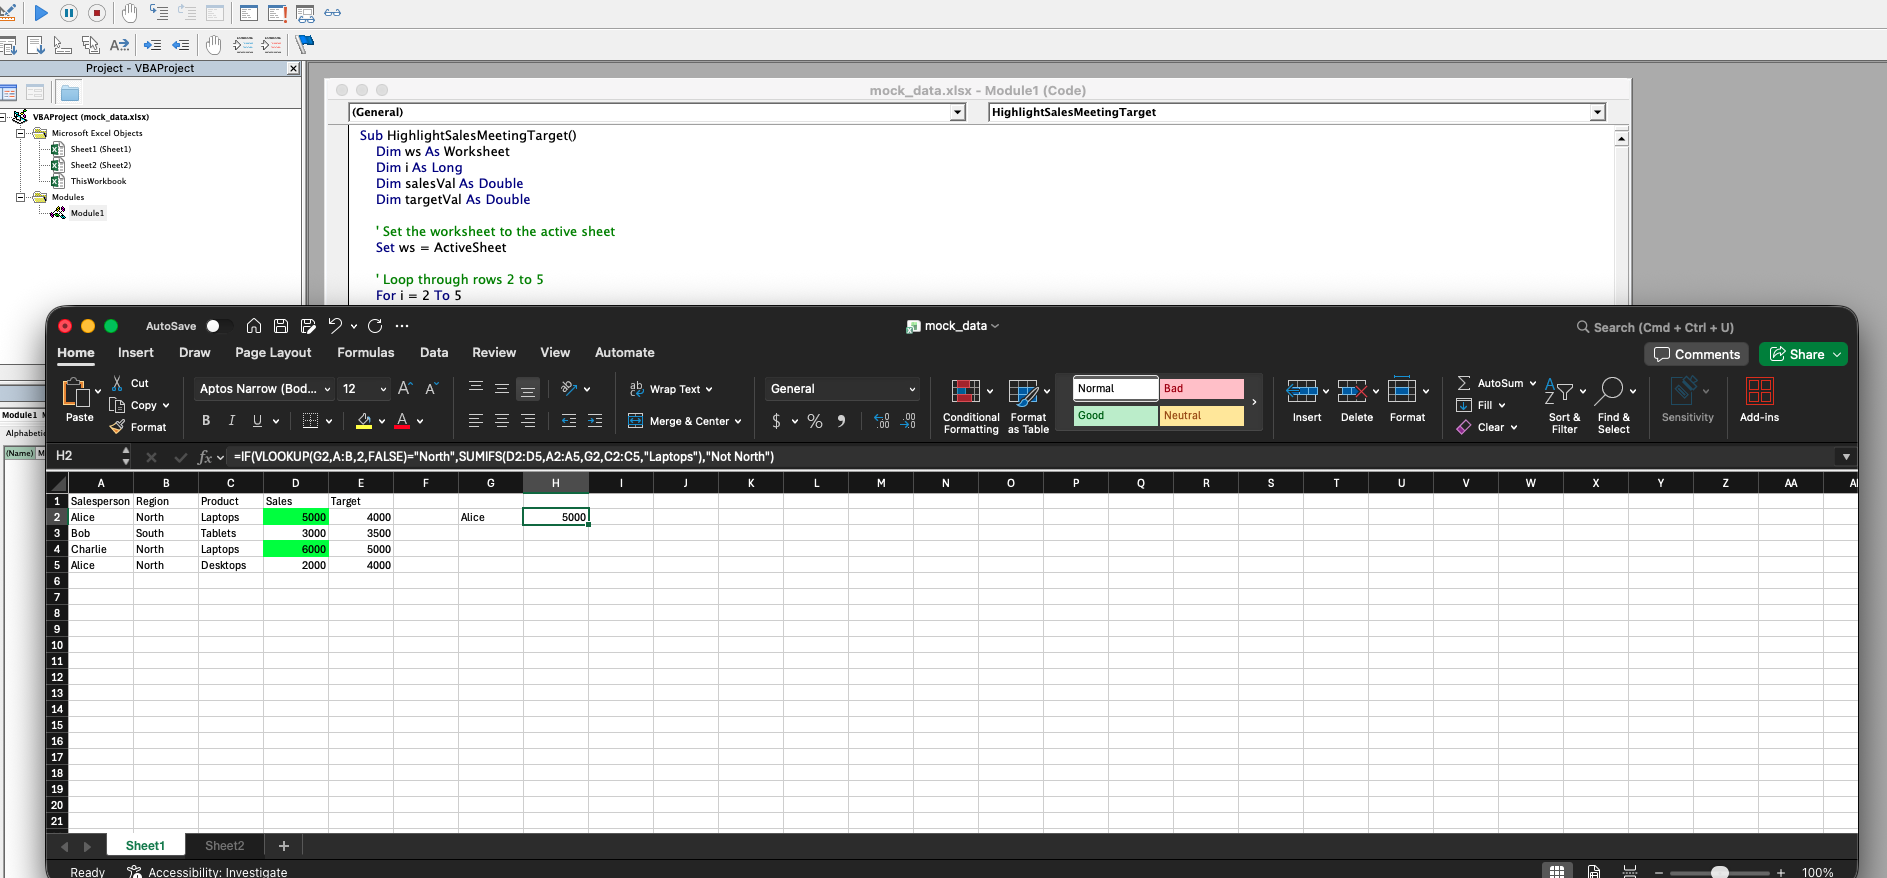

<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); padding: 24px 30px; border-radius: 12px; margin: 24px 0 0; text-align: center;">
  <h2 style="color: white; margin: 0 0 10px;">🎉 Lab 1 Complete!</h2>
  <p style="color: rgba(255,255,255,0.85); margin: 0; font-size: 14px;">You've built an AI-powered Excel assistant that generates formulas, VBA macros, and analysis from natural language.</p>
  <div style="background: rgba(255,255,255,0.15); border-radius: 8px; padding: 12px; margin-top: 14px; text-align: left;">
    <p style="color: white; margin: 0 0 6px; font-weight: bold; font-size: 14px;">Key Takeaways:</p>
    <ul style="color: rgba(255,255,255,0.9); margin: 0; font-size: 13px;">
      <li><b>System messages</b> control the output format — formula, VBA code, or prose analysis</li>
      <li>Strict prompts like <i>"Return ONLY the formula"</i> produce <b>paste-ready</b> output for Excel</li>
      <li>One reusable function with <b>mode-based system messages</b> handles multiple use cases</li>
      <li>The same API + different prompts = completely different output types</li>
    </ul>
  </div>
  <p style="color: rgba(255,255,255,0.7); margin: 14px 0 0; font-size: 13px;"><b>Next →</b> M02 Lab 2: Bitcoin Analyzer</p>
</div>